# L07 Worked Solutions — Analysis Visualisation

**Course:** AAU E26 — Introduction to Scripting, Data Mining and Machine Learning  
**Lecture:** Lecture 7 — Exploratory analysis, introductory text analysis and data visualisation  
**Goal:** Practise descriptive statistics, grouping, chart selection, and cautious interpretation.

[Open this notebook in Google Colab](https://colab.research.google.com/github/asmrabbi/E26_TAN7_Scripting_CPH/blob/main/notebooks/solutions/L07_solutions_analysis_visualisation.ipynb) · [View the course repository](https://github.com/asmrabbi/E26_TAN7_Scripting_CPH)

Run the cells from top to bottom. Every executable line includes a short comment explaining what it does.


## Goal

Practise descriptive statistics, grouping, chart selection, and cautious interpretation.


## Setup

A complete worked solution follows.

### Running this notebook on a local computer

1. Download or clone the course repository.
2. Open a terminal in the repository folder.
3. Create and activate a virtual environment.
4. Install the shared requirements with `python -m pip install -r requirements.txt`.
5. Start Jupyter with `python -m jupyter lab`.

Packages used directly in this notebook: `matplotlib pandas`

## Steps

1. Prepare the minimum valid analysis subset and state the exclusions.
2. Calculate mean and median resolution time by city with denominators.
3. Create one clearly labelled comparison chart.
4. Write one supported observation and two conclusions the chart cannot establish.


   record_id report_month          city service_type  cases_received  \
0       1001   2026-01-01    Copenhagen      Housing             120   
1       1002   2026-01-01   copenhagen     Transport              85   
2       1003   2026-01-01       AALBORG      Housing              -3   
3       1004   2026-02-01    Koebenhavn   Employment              74   
4       1004   2026-02-01    Koebenhavn   Employment              74   

   cases_resolved resolution_days  satisfaction_score  \
0             112             5.1                 4.2   
1              90             3.2                 4.6   
2               0             8.4                 3.1   
3              68             4.0                 4.0   
4              68             4.0                 4.0   

                                  feedback  
0           Helpful staff and clear answer  
1  Quick answer but the form was confusing  
2                  Long wait for an answer  
3                   The guidance was clear  

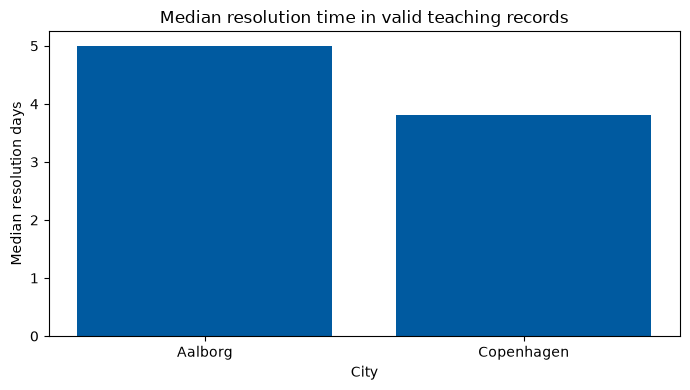

Supported: median resolution time differs across the valid teaching records shown.
Not supported: city caused the difference.
Not supported: the same pattern will hold for all future service reports.


In [1]:
from pathlib import Path  # Imports Path so the notebook can find a local course file when available.
import pandas as pd  # Imports pandas for reading and working with table-shaped data.
remote_data_url = "https://raw.githubusercontent.com/asmrabbi/E26_TAN7_Scripting_CPH/main/data/monthly_service_report.csv"  # Stores the public GitHub address used by Google Colab.
local_data_candidates = [Path("data/monthly_service_report.csv"), Path("../../data/monthly_service_report.csv")]  # Lists possible local paths used during validation.
data_source = next((path for path in local_data_candidates if path.exists()), remote_data_url)  # Chooses a local file when present and otherwise uses GitHub.
exercise_data = pd.read_csv(data_source)  # Reads the CSV file into a pandas DataFrame.
print(exercise_data.head())  # Prints a small preview so we can confirm that loading worked.
import matplotlib.pyplot as plt  # Imports plotting tools for the exercise.
exercise_data["city"] = exercise_data["city"].astype("string").str.strip().str.lower().replace({"koebenhavn": "copenhagen"}).str.title()  # Standardises documented city variants.
exercise_data["resolution_days"] = pd.to_numeric(exercise_data["resolution_days"], errors="coerce")  # Converts resolution times into numbers.
exercise_data = exercise_data.drop_duplicates().copy()  # Removes confirmed exact duplicates.
analysis_subset = exercise_data[exercise_data["resolution_days"].ge(0) & exercise_data["resolution_days"].notna()].copy()  # Keeps non-missing, non-negative resolution times for this summary.
city_summary = analysis_subset.groupby("city")["resolution_days"].agg(["count", "mean", "median"]).reset_index()  # Calculates denominators and two centre measures by city.
print(city_summary.round(2))  # Displays the complete grouped result table.
plt.figure(figsize=(7, 4))  # Creates a readable classroom figure.
plt.bar(city_summary["city"], city_summary["median"], color="#005AA0")  # Draws median resolution time for each city.
plt.title("Median resolution time in valid teaching records")  # Names the measure and restricted data scope.
plt.xlabel("City")  # Labels the categorical horizontal axis.
plt.ylabel("Median resolution days")  # Labels the numeric vertical axis and unit.
plt.ylim(bottom=0)  # Starts the bar-chart axis at zero to avoid exaggerating differences.
plt.tight_layout()  # Keeps labels within the plotted figure.
plt.show()  # Displays the completed chart.
print("Supported: median resolution time differs across the valid teaching records shown.")  # States a descriptive observation tied to the plotted subset.
print("Not supported: city caused the difference.")  # Rejects a causal conclusion that the chart cannot establish.
print("Not supported: the same pattern will hold for all future service reports.")  # Rejects an unsupported generalisation beyond the data.


## Checks

The grouped table must include counts. The bar-chart axis must begin at zero, and the interpretation must name the restricted teaching dataset.


## Next Steps

Change one input, predict the result before running, and explain any difference between the expected and observed output.
